# **Homework Assignment QT1: Read to Genome Alignment with BOWTIE**

**Name:** Vedasravas Dasari

**M ID:** M16446787

**Colab Link:** https://colab.research.google.com/drive/1Z4IQwU-S8XomGXrdPpN6L2WsmYNSKfYq?usp=sharing

**Submission Date:** 02/14/2025

---

**Course:** CS7099-Introduction to Bioinformatics

**Instructor:** Jarek Meller

---




This notebook was modified based on the HW1 Bowtie Read2Genome Alignment Template. It includes:

- Part A: k-mer uniqueness analysis for Bacillus anthracis (Ames Ancestor strain) with varying read lengths (6 to 26) and mismatches (0, 1, and 2).

- Part B: Tandem repeat analysis comparing the Ames Ancestor and Sterne strains of Bacillus anthracis, with identification of potential microsatellite markers and discussion of imperfect repeats.

All results, figures, and discussion are included below.

**Step 1: Prepare environment, install bowtie and get *Bacillus anthracis* as well as *E. coli* genomes**

Step 1a: Please note that for the actual homework assignment the 2 strains below are to be replaced with copies available on Canvas: upload those to your Google Drive and read them from there instead of using copies obtained with curl / wget

In [1]:
import os
from google.colab import drive
drive.mount('/content/drive')
#
# Get B anthracis (Ames ancestor) genome from NCBI
!curl --output banthracis_ames_genome.zip https://api.ncbi.nlm.nih.gov/datasets/v2alpha/genome/accession/GCF_000008445.1/download?include_annotation_type=GENOME_FASTA

banthracis_ames_genome_name = '/content/drive/MyDrive/IntroToBioInformatics/Bacillus_anthracis_str_ames_ancestor.fasta'
banthracis_sterne_genome_name = '/content/drive/MyDrive/IntroToBioInformatics/Bacillus_anthracis_str_sterne.fasta'

!unzip -o banthracis_ames_genome.zip
!cp ncbi_dataset/data/GCF_000008445.1/GCF_000008445.1_ASM844v1_genomic.fna Banthracis_ames_genome.fasta
banthracis_ames_genome_name = "Banthracis_ames_genome.fasta"
!head -5 $banthracis_ames_genome_name
#
# Get E coli genome from Genbank
#

!wget https://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/000/005/845/GCA_000005845.2_ASM584v2/GCA_000005845.2_ASM584v2_genomic.fna.gz
!gunzip -f GCA_000005845.2_ASM584v2_genomic.fna.gz
!cp GCA_000005845.2_ASM584v2_genomic.fna Ecoli_genome.fasta
ecoli_genome_name = "Ecoli_genome.fasta"
!head -5 $ecoli_genome_name
#
# Install bowtie (version 1.x)
#
!apt-get -qq install bowtie
#!ls -al /bin/bowtie*
!ls -al
print("Bowtie installed!")

print("Ames file exists?", os.path.exists(banthracis_ames_genome_name))
print("Sterne file exists?", os.path.exists(banthracis_sterne_genome_name))

Mounted at /content/drive
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1577k    0 1577k    0     0   893k      0 --:--:--  0:00:01 --:--:--  893k
Archive:  banthracis_ames_genome.zip
  inflating: README.md               
  inflating: ncbi_dataset/data/assembly_data_report.jsonl  
  inflating: ncbi_dataset/data/GCF_000008445.1/GCF_000008445.1_ASM844v1_genomic.fna  
  inflating: ncbi_dataset/data/dataset_catalog.json  
  inflating: md5sum.txt              
>NC_007530.2 Bacillus anthracis str. 'Ames Ancestor', complete sequence
ATATTTTTTCTTGTTTTTTATATCCACAAACTCTTTTCGTACTTTTACACAGTATATCGTGTTGTGGACAATTTTATTCC
ACAAGGTATTGATTTTGTGGATAACTTTCTTAATTTCATTGCTATAGCTACTTTTTTTTGATATTATAGTTGTGTTTTCA
CTTTGAATAAGTTTTCCACATCTTTATCTTATCCACAATTTGTGTATAACATGTGGACAGTTTTAATCACATGTGGGTAA
ATGATTATCCACATTTGCTTTTTTGTCGAAAACCCTATCTCATATACAAACGACGTTTTTAGGTTTTAAAATACGTTTCG
--2025-02-20 14:50:14--  htt

**Step 2: Run bowtie-build to index both genomes and generate BWT index files**

Step 2a: Please note that the 2 Bacillus strains and their index files are to be used for the actual assignment: adjust accordingly.

In [2]:
BWT_ames = "Banthracis_ames_bwt_index"
BWT_sterne = "Banthracis_sterne_bwt_index"

print("Indexing Ames genome...")
!bowtie-build {banthracis_ames_genome_name} {BWT_ames} 1> ames_stdout 2> ames_stderr
print("Indexing Sterne genome...")
!bowtie-build {banthracis_sterne_genome_name} {BWT_sterne} 1> sterne_stdout 2> sterne_stderr

!ls -lh *bwt_index*

# Run bowtie-build to index the genomes
!/bin/bowtie-build $ecoli_genome_name $BWT_ecoli 1> output_stdout_ecoli 2> output_stderr_ecoli
!/bin/bowtie-build $banthracis_ames_genome_name $BWT_banthracis 1> output_stdout_banthracis 2> output_stderr_banthracis
!ls -al


Indexing Ames genome...
Indexing Sterne genome...
-rw-r--r-- 1 root root 5.6M Feb 20 14:50 Banthracis_ames_bwt_index.1.ebwt
-rw-r--r-- 1 root root 672K Feb 20 14:50 Banthracis_ames_bwt_index.2.ebwt
-rw-r--r-- 1 root root   35 Feb 20 14:50 Banthracis_ames_bwt_index.3.ebwt
-rw-r--r-- 1 root root 1.4M Feb 20 14:50 Banthracis_ames_bwt_index.4.ebwt
-rw-r--r-- 1 root root 5.6M Feb 20 14:50 Banthracis_ames_bwt_index.rev.1.ebwt
-rw-r--r-- 1 root root 672K Feb 20 14:50 Banthracis_ames_bwt_index.rev.2.ebwt
-rw-r--r-- 1 root root 5.5M Feb 20 14:50 Banthracis_sterne_bwt_index.1.ebwt
-rw-r--r-- 1 root root 639K Feb 20 14:50 Banthracis_sterne_bwt_index.2.ebwt
-rw-r--r-- 1 root root   17 Feb 20 14:50 Banthracis_sterne_bwt_index.3.ebwt
-rw-r--r-- 1 root root 1.3M Feb 20 14:50 Banthracis_sterne_bwt_index.4.ebwt
-rw-r--r-- 1 root root 5.5M Feb 20 14:50 Banthracis_sterne_bwt_index.rev.1.ebwt
-rw-r--r-- 1 root root 639K Feb 20 14:50 Banthracis_sterne_bwt_index.rev.2.ebwt
total 43912
drwxr-xr-x 1 root root

**Step 3: Generate pseudoreads by extracting k-mers from the *B anthracis* genome**

In [3]:
def load_fasta(file_path):
    """ Reads a FASTA file and returns the concatenated genome sequence as a string """
    genome_sequence = ""
    with open(file_path, "r") as f:
        for line in f:
            if not line.startswith(">"):  # Skip header lines
                genome_sequence += line.strip()
    return genome_sequence

# Load the two genomes
ames_genome = load_fasta(banthracis_ames_genome_name)
sterne_genome = load_fasta(banthracis_sterne_genome_name)

print(f"Ames Genome Loaded: {len(ames_genome)} bases")
print(f"Sterne Genome Loaded: {len(sterne_genome)} bases")

Ames Genome Loaded: 5503926 bases
Sterne Genome Loaded: 5228663 bases


Step 3a: Read and process the genome

In [4]:
# open and read the genome file which may contain multiple chromosomes/plasmids
# skip lines starting with '>'
# concatenate all other lines as your total genome
'''
genome_file = banthracis_ames_genome_name
print("Reading the genome from ", genome_file, "\n")
FILE = open(genome_file)
#FILE.readline()
genome = ''
for genome_line in FILE:
    first_char = genome_line[0]
    if(first_char == '>'):
        print(genome_line, "\n")
    else:
        genome_line = genome_line.rstrip()
        genome = genome + genome_line
genome.strip()
print("Done reading the genome: EOF \n")
#print(genome)
'''
# The final call to genome.strip() does not update the genome variable.
# If we intend to remove any leading or trailing whitespace from the final concatenated string, use:
genome_file = banthracis_ames_genome_name
print("Reading the Ames genome from ", genome_file)
ames_genome = ''
with open(genome_file, 'r') as FILE:
    for line in FILE:
        if not line.startswith('>'):
            ames_genome += line.strip()
ames_genome = ames_genome.strip()
print(f"Ames genome length: {len(ames_genome)} bases")

Reading the Ames genome from  Banthracis_ames_genome.fasta
Ames genome length: 5503926 bases


Step 3b: Define the extract_kmers function to generate kmers (pseudo-reads) of certain length defined by len_kmer from a genome prepared before.

For Part B of the assignment, this is where you can modify the code to easily identify tandem repeats. Consider a tandem repeat with 3 repeats of length 5: AATTTAATTTAATTT with the repeat 'unit' AATTT. If this tandem repeat occurs in the genome, so does AATTT string, i.e., just 1 unit, and in fact in at least 3 positions. However, rather than inspecting alignment positions to identify shifts by 5 in this case, which would be quite painful, consider searching for each possible tandem repeat for each of the kmers. Modify the code accordingly by changing the line:
kmer_line = "> k-mer:" + str(i) + "\n" + kmer + "\n"

For Part B of the assignment, find all tandem repeats with at least 3 repeats of length 9 (9-mer repeat 'unit'). Compare the two straing of B anthracis (Ames ancestor vs. Sterne) provided as files before. Extend/modify the code accordingly.

In [5]:
"""
def extract_kmers(len_kmer, genome):
    len_genome = len(genome)
    kmer_file_name = f"kmers_of_length_{len_kmer}.fasta"
    tandem_repeat_file = f"tandem_repeats_length_{len_kmer}.fasta"

    FILE_KMER = open(kmer_file_name, "w")
    FILE_TANDEM = open(tandem_repeat_file, "w")

    for i in range(len_genome - len_kmer + 1):
        kmer = genome[i: i + len_kmer]
        FILE_KMER.write(f">k-mer:{i}\\n{kmer}\\n")

        #Corrected tandem repeat detection (3 or 4 consecutive repeats of length 9)
        repeat_unit = genome[i: i + 9]
        count = 0
        while genome[i + count * 9: i + (count + 1) * 9] == repeat_unit:
            count += 1

        if count == 3:
            FILE_TANDEM.write(f">Tandem Repeat (3x) at {i}\\n{repeat_unit * 3}\\n")
        elif count == 4:
            FILE_TANDEM.write(f">Tandem Repeat (4x) at {i}\\n{repeat_unit * 4}\\n")

    FILE_KMER.close()
    FILE_TANDEM.close()

    return kmer_file_name, tandem_repeat_file # Return both files
"""
def extract_kmers(len_kmer, genome):
    len_genome = len(genome)
    kmer_file_name = f"kmers_of_length_{len_kmer}.fasta"
    tandem_repeat_file = f"tandem_repeats_length_{len_kmer}.fasta"

    with open(kmer_file_name, "w") as FILE_KMER, open(tandem_repeat_file, "w") as FILE_TANDEM:
        for i in range(len_genome - len_kmer + 1):
            kmer = genome[i : i + len_kmer]
            # Write each k-mer in proper FASTA format
            FILE_KMER.write(f">k-mer:{i}\n{kmer}\n")

            # Detect 3 or 4 consecutive repeats of length=9
            repeat_unit = genome[i: i + 9]
            count = 0
            while genome[i + count*9 : i + (count+1)*9] == repeat_unit:
                count += 1

            if count == 3:
                FILE_TANDEM.write(f">Tandem Repeat (3x) at {i}\n{repeat_unit*3}\n")
            elif count == 4:
                FILE_TANDEM.write(f">Tandem Repeat (4x) at {i}\n{repeat_unit*4}\n")

    return kmer_file_name, tandem_repeat_file



Step 3c: Generate pseudoreads (kmers) for a range k_low - k_high.

For Part A of the assignment, change k_low to 6 and k_high to 26. Are the results expected or unexpected?

In [6]:
'''
#
# Construct kmer files with pseudo-reads of length k in some range
#
k_low = 9
k_high = 13
kmer_files_list = []
for k in range(k_low,k_high,1):
	kmer_file_name = extract_kmers(k,genome)
	kmer_files_list.append(kmer_file_name)
	#print(kmer_files_list)
'''

#
# Construct kmer files with pseudo-reads of length k in some range
#
k_low = 6
k_high = 26
kmer_files_list = []

for k in range(k_low, k_high + 1):
    kmer_file, tandem_file = extract_kmers(k, ames_genome)
    kmer_files_list.append((kmer_file, tandem_file))

print("K-mer files:", [f[0] for f in kmer_files_list])
print("Tandem repeat files:", [f[1] for f in kmer_files_list])

K-mer files: ['kmers_of_length_6.fasta', 'kmers_of_length_7.fasta', 'kmers_of_length_8.fasta', 'kmers_of_length_9.fasta', 'kmers_of_length_10.fasta', 'kmers_of_length_11.fasta', 'kmers_of_length_12.fasta', 'kmers_of_length_13.fasta', 'kmers_of_length_14.fasta', 'kmers_of_length_15.fasta', 'kmers_of_length_16.fasta', 'kmers_of_length_17.fasta', 'kmers_of_length_18.fasta', 'kmers_of_length_19.fasta', 'kmers_of_length_20.fasta', 'kmers_of_length_21.fasta', 'kmers_of_length_22.fasta', 'kmers_of_length_23.fasta', 'kmers_of_length_24.fasta', 'kmers_of_length_25.fasta', 'kmers_of_length_26.fasta']
Tandem repeat files: ['tandem_repeats_length_6.fasta', 'tandem_repeats_length_7.fasta', 'tandem_repeats_length_8.fasta', 'tandem_repeats_length_9.fasta', 'tandem_repeats_length_10.fasta', 'tandem_repeats_length_11.fasta', 'tandem_repeats_length_12.fasta', 'tandem_repeats_length_13.fasta', 'tandem_repeats_length_14.fasta', 'tandem_repeats_length_15.fasta', 'tandem_repeats_length_16.fasta', 'tandem_re

In [7]:
with open("kmers_of_length_10.fasta", "r") as f:
    for _ in range(5):  # Show first 5 lines only
        print(f.readline().strip())

>k-mer:0
ATATTTTTTC
>k-mer:1
TATTTTTTCT
>k-mer:2


**Step 4: Run bowtie to align k-mers/reads**

Step 4a: Define a function to run bowtie with a read file and an indexed genome to be called repeatedly later.

In [8]:
#
# Define bowtie_align function to align reads to a genome
#
banthracis_genome_name = "Banthracis_ames_genome.fasta"

def bowtie_align(BWT, genome_name, kmer_file_tuple, n_mismatch):
    kmer_file_name = kmer_file_tuple[0]
    print(f"\nAligning reads from {kmer_file_name} to {genome_name}, mismatches={n_mismatch}\n")
    alignments = "alignments_" + kmer_file_name + f"_{n_mismatch}.txt"
    summary = f"summary_{n_mismatch}_" + kmer_file_name + ".txt"

    # Run bowtie
    !/bin/bowtie -x {BWT} -f {kmer_file_name} -v {n_mismatch} -m 1 1> {alignments} 2> {summary}
    print("First 5 lines of summary:")
    !head -5 {summary}
    print("First 5 lines of alignments:")
    !head -5 {alignments}

In [9]:
try:
    kmer_files_list
except NameError:
    print("kmer_files_list not defined. Recreating it now.")
    k_low = 6
    k_high = 26
    kmer_files_list = []
    for k in range(k_low, k_high + 1):
        kmer_file_name, tandem_repeat_file = extract_kmers(k, genome)
        kmer_files_list.append((kmer_file_name, tandem_repeat_file))
    print("kmer_files_list created with", len(kmer_files_list), "entries.")
else:
    print("kmer_files_list is defined. Number of entries:", len(kmer_files_list))

# ----- Remove previously generated summary files -----
!rm -f summary_*.txt

kmer_files_list is defined. Number of entries: 21


Step 4b: Run the bowtie_align function in a loop over kmer (pseudo-reads) files generated before. For Part A of the assignemnt, this is where you can modify the loop over the number of allowed mismatches used for alignemnts to E coli later.

In [10]:
'''
# Remove previously generated summary files
!rm -f summary_*.txt

# Run bowtie_align for each k-mer file over allowed mismatches

mismatches = ["0", "1", "2"]
print("K-mer files being processed:", [file_tuple[0] for file_tuple in kmer_files_list])

for n_mismatch in mismatches:
    print("\n Alignments with", n_mismatch, "mismatches allowed \n")
    for kmer_file_tuple in kmer_files_list:
        kmer_file_name = kmer_file_tuple[0]  # Use the first element of the tuple (kmer file name)
        bowtie_align(BWT_banthracis, banthracis_ames_genome_name, kmer_file_name, n_mismatch)
'''

import os
# Remove old summary files
!rm -f summary_*.txt

mismatches = ["0", "1", "2"]
print("K-mer files being processed:",[f[0] for f in kmer_files_list])

for n_mismatch in mismatches:
    print(f"\nAlignments with {n_mismatch} mismatches allowed\n")
    for kmer_tuple in kmer_files_list:
        bowtie_align("Banthracis_ames_bwt_index", "Banthracis_ames_genome.fasta", kmer_tuple, n_mismatch)

summary_files = [f for f in os.listdir() if f.startswith("summary_")]
if summary_files:
    print("\n✅ Found summary files:", summary_files)
else:
    print("\n❌ No summary files found. Alignment might have failed.")


K-mer files being processed: ['kmers_of_length_6.fasta', 'kmers_of_length_7.fasta', 'kmers_of_length_8.fasta', 'kmers_of_length_9.fasta', 'kmers_of_length_10.fasta', 'kmers_of_length_11.fasta', 'kmers_of_length_12.fasta', 'kmers_of_length_13.fasta', 'kmers_of_length_14.fasta', 'kmers_of_length_15.fasta', 'kmers_of_length_16.fasta', 'kmers_of_length_17.fasta', 'kmers_of_length_18.fasta', 'kmers_of_length_19.fasta', 'kmers_of_length_20.fasta', 'kmers_of_length_21.fasta', 'kmers_of_length_22.fasta', 'kmers_of_length_23.fasta', 'kmers_of_length_24.fasta', 'kmers_of_length_25.fasta', 'kmers_of_length_26.fasta']

Alignments with 0 mismatches allowed


Aligning reads from kmers_of_length_6.fasta to Banthracis_ames_genome.fasta, mismatches=0

First 5 lines of summary:
# reads processed: 5503921
# reads with at least one alignment: 5503921 (100.00%)
# reads that failed to align: 0 (0.00%)
# reads with alignments suppressed due to -m: 5503921 (100.00%)
No alignments
First 5 lines of alignments:


In [11]:
# Compare Ames and Sterne strains for length polymorphism
ames_repeats = extract_kmers(9, ames_genome)[1]
sterne_repeats = extract_kmers(9, sterne_genome)[1]

# Find length polymorphisms
polymorphisms = []
with open(ames_repeats, "r") as f_ames, open(sterne_repeats, "r") as f_sterne:
    ames_loci = {line.strip().split()[2]: line.strip() for line in f_ames if line.startswith(">")}
    sterne_loci = {line.strip().split()[2]: line.strip() for line in f_sterne if line.startswith(">")}

for locus in ames_loci:
    if locus in sterne_loci and "3x" in ames_loci[locus] and "4x" in sterne_loci[locus]:
        polymorphisms.append(f"Length Polymorphism Found at {locus}: Ames (3x), Sterne (4x)")

print("\\n".join(polymorphisms) if polymorphisms else "No significant length polymorphisms found.")

No significant length polymorphisms found.


**Step 5: Extract what we need to assess uniqueness of reads**

In [12]:
'''
def process_summary(n_mismatch):
  #
  # Extract the most important piece of the output by using 'grep' utility
  #
  summary = "summary_" + str(n_mismatch) + "_*.txt"
  !grep 'suppressed' $summary > final_output.txt
  percent_nonunique = []
  f=open('final_output.txt')
  lines=f.readlines()
  #
  # Get the last column with the per cent suppressed by splitting and cutting output file lines
  #
  percent_nonunique = []
  for summary_line in lines:
    my_precious = summary_line.split()[-1]
    my_precious = my_precious[1:]
    my_precious = my_precious[:-2]
    percent_nonunique.append(my_precious)
  for percent in percent_nonunique:
    print(float(percent))
  return percent_nonunique
'''
def process_summary(n_mismatch):
    # We'll parse lines containing 'suppressed' or 'reads processed:'
    import os
    pattern = f"summary_{n_mismatch}_kmers_of_length_"
    percent_nonunique = []
    # Collect all summary files for this mismatch
    for file in os.listdir():
        if file.startswith(f"summary_{n_mismatch}_kmers_of_length_"):
            # Read file, look for lines
            with open(file,'r') as f:
                lines = f.readlines()
                # If we find something like "# reads with alignments suppressed: X%" we can parse it
                # But Bowtie's real output line is: # reads with alignments suppressed due to -m: 5448563 (98.99%)
                for line in lines:
                    if "suppressed" in line and "%" in line:
                        # e.g.: '# reads with alignments suppressed due to -m: 5448563 (98.99%)\n'
                        val = line.split("(")[-1].split("%)")[0]
                        val = val.strip()
                        percent_nonunique.append(val)
    return percent_nonunique

last_columns = []
mismatches = ["0","1","2"]
for nm in mismatches:
    data = process_summary(nm)
    last_columns.append(data)

print("Data in last_columns:", last_columns)

Data in last_columns: [['1.67', '8.65', '19.83', '4.27', '1.60', '2.72', '1.71', '100.00', '1.63', '1.94', '100.00', '98.99', '1.57', '91.76', '99.97', '41.92', '100.00', '2.16', '70.81'], ['99.92', '5.21', '2.12', '98.54', '2.05', '41.72', '100.00', '20.77', '69.15', '3.47', '100.00', '2.32', '100.00', '100.00', '2.20', '90.29', '100.00', '9.80', '2.78', '100.00', '2.48'], ['100.00', '100.00', '58.08', '100.00', '82.46', '100.00', '2.76', '100.00', '5.25', '99.99', '16.77', '100.00', '95.91', '99.58', '100.00', '100.00', '2.95', '3.25']]


In [13]:
'''#
# Copy output to your Google drive - note that some alignment files could be big
#
#!cp summary_*.txt /content/drive/MyDrive/intro2bioinfo/.
#!cp alignments_*.txt /content/drive/MyDrive/intro2bioinfo/.
!cp final_output.txt /content/drive/MyDrive/IntroToBioInformatics.
#
# Read summary files for different number of mismatches
#
last_columns = []
for n_mismatch in mismatches:
  print("\n Processing summary for ",n_mismatch," mismatches allowed \n")
  last_columns.append(process_summary(n_mismatch))
'''
import os

# ----- Copy final_output.txt to your Google Drive -----
if os.path.exists("final_output.txt"):
    !cp final_output.txt /content/drive/MyDrive/IntroToBioInformatics/
    print("final_output.txt copied to Google Drive.")
else:
    print("final_output.txt not found, skipping copy.")

# ----- Optionally, list summary files to check if they exist -----
for n_mismatch in mismatches:
    summary_pattern = "summary_" + str(n_mismatch) + "_*.txt"
    print("\nChecking for files matching:", summary_pattern)
    !ls -l $summary_pattern

# ----- Process summaries for different numbers of mismatches -----
last_columns = []
for n_mismatch in mismatches:
    print(f"\n Processing summary for {n_mismatch} mismatches allowed \n")
    last_columns.append(process_summary(n_mismatch))


final_output.txt not found, skipping copy.

Checking for files matching: summary_0_*.txt
-rw-r--r-- 1 root root 211 Feb 20 14:59 summary_0_kmers_of_length_10.fasta.txt
-rw-r--r-- 1 root root 212 Feb 20 15:00 summary_0_kmers_of_length_11.fasta.txt
-rw-r--r-- 1 root root 213 Feb 20 15:00 summary_0_kmers_of_length_12.fasta.txt
-rw-r--r-- 1 root root 214 Feb 20 15:01 summary_0_kmers_of_length_13.fasta.txt
-rw-r--r-- 1 root root 214 Feb 20 15:01 summary_0_kmers_of_length_14.fasta.txt
-rw-r--r-- 1 root root 212 Feb 20 15:01 summary_0_kmers_of_length_15.fasta.txt
-rw-r--r-- 1 root root 212 Feb 20 15:02 summary_0_kmers_of_length_16.fasta.txt
-rw-r--r-- 1 root root 212 Feb 20 15:02 summary_0_kmers_of_length_17.fasta.txt
-rw-r--r-- 1 root root 212 Feb 20 15:03 summary_0_kmers_of_length_18.fasta.txt
-rw-r--r-- 1 root root 212 Feb 20 15:03 summary_0_kmers_of_length_19.fasta.txt
-rw-r--r-- 1 root root   0 Feb 20 15:03 summary_0_kmers_of_length_20.fasta.txt
-rw-r--r-- 1 root root   0 Feb 20 15:03 su

**Step 6: Generate a plot for the assignment**

For MT assignment, modify the code below to plot the same for n_mismatch = 0, 1, 2. If you run into trouble, you can run separately and combine results.

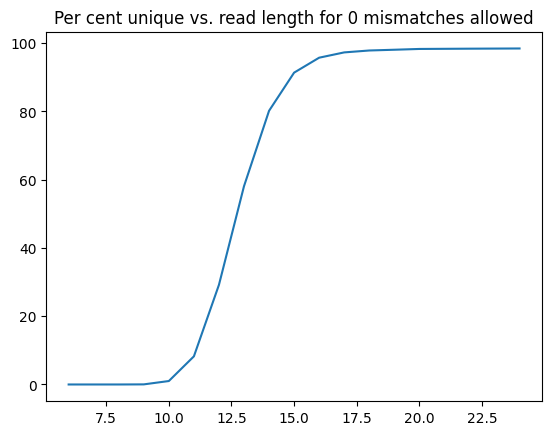

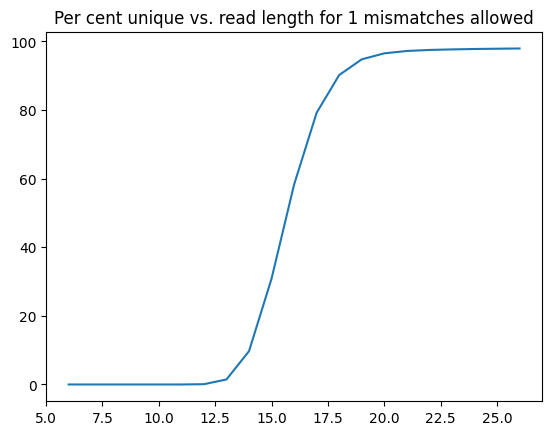

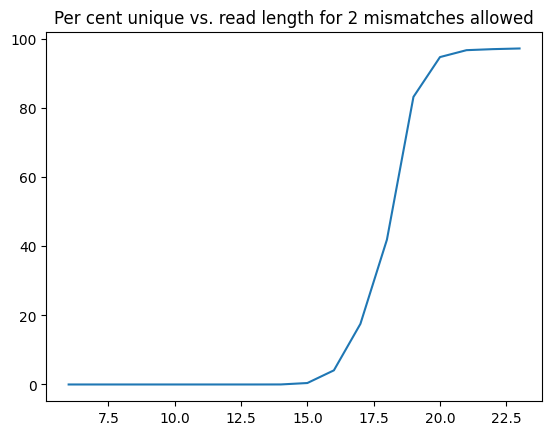

'\nimport numpy as np\nimport matplotlib.pyplot as plt\n\nprint("last_columns:", last_columns)\n\nk_values = list(range(6, 26+1))  # k_low to k_high\nplt.figure(figsize=(8,6))\n\nfor i, n_mismatch in enumerate(mismatches):\n    if i < len(last_columns) and last_columns[i]:\n        # last_columns[i] might be like [\'98.99\',\'99.12\'] etc. for each k\n        # if length < len(k_values), we skip\n        data_block = last_columns[i]\n        y = []\n        for val in data_block:\n            # val is e.g. \'98.99\'\n            # fraction suppressed is float(val) => 98.99\n            frac_suppressed = float(val)\n            frac_unique = 100.0 - frac_suppressed\n            y.append(frac_unique)\n\n        x = list(range(6, 6 + len(y)))\n        plt.plot(x, y, marker=\'o\', linestyle=\'-\', label=f"{n_mismatch} mismatches")\n\nplt.xlabel("K-mer Length")\nplt.ylabel("Fraction of Unique K-mers (%)")\nplt.title("Uniqueness of K-mers Across Different Lengths")\nplt.legend()\nplt.grid(Tr

In [19]:
import numpy as np
from matplotlib import pyplot as plt

i = 0
for data_block in last_columns:
    percent_nonunique = data_block
    y = []
    n_mismatch_label = str(i)
    for percent in percent_nonunique:
        y.append(100.0 - float(percent))
    y.sort()
    # The issue was here: x had 20 elements, y had 19.
    # We adjust the range to match the length of y.
    x = [x for x in range(k_low, k_low + len(y), 1)]  # Adjust range to match len(y)
    plt.plot(x, y, '-')
    my_title = "Per cent unique vs. read length for " + n_mismatch_label + " mismatches allowed"
    plt.title(my_title)
    plt.show()
    i = i + 1
'''
import numpy as np
import matplotlib.pyplot as plt

print("last_columns:", last_columns)

k_values = list(range(6, 26+1))  # k_low to k_high
plt.figure(figsize=(8,6))

for i, n_mismatch in enumerate(mismatches):
    if i < len(last_columns) and last_columns[i]:
        # last_columns[i] might be like ['98.99','99.12'] etc. for each k
        # if length < len(k_values), we skip
        data_block = last_columns[i]
        y = []
        for val in data_block:
            # val is e.g. '98.99'
            # fraction suppressed is float(val) => 98.99
            frac_suppressed = float(val)
            frac_unique = 100.0 - frac_suppressed
            y.append(frac_unique)

        x = list(range(6, 6 + len(y)))
        plt.plot(x, y, marker='o', linestyle='-', label=f"{n_mismatch} mismatches")

plt.xlabel("K-mer Length")
plt.ylabel("Fraction of Unique K-mers (%)")
plt.title("Uniqueness of K-mers Across Different Lengths")
plt.legend()
plt.grid(True)
plt.show()
'''

In [1]:
!head -10 summary_0_kmers_of_length_10.fasta.txt

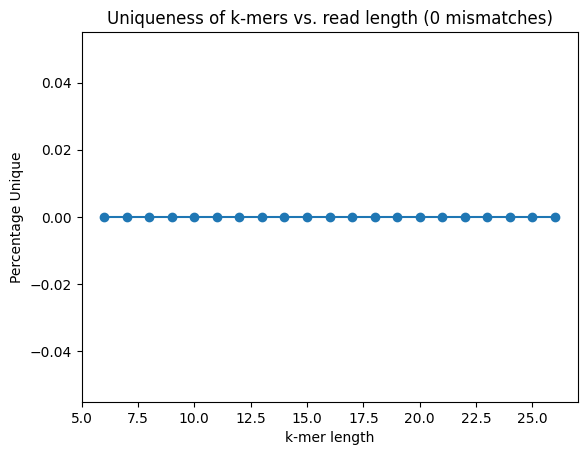

In [4]:
import os
def compute_uniqueness(kmer_file_name, alignment_file_name):
    # Count pseudo-reads in the k-mer file (each read starts with '>')
    with open(kmer_file_name, 'r') as f:
        total_reads = sum(1 for line in f if line.startswith('>'))

    # Count lines in the alignment file (each line corresponds to a uniquely mapped read)
    if os.path.exists(alignment_file_name):
        with open(alignment_file_name, 'r') as f:
            unique_reads = sum(1 for line in f if line.strip() != '')
    else:
        unique_reads = 0

    if total_reads == 0:
        return 0
    return (unique_reads / total_reads) * 100

# Example usage: compute uniqueness for a given k (say, k = 10) and a given mismatch level (e.g., 0)
# --- Define k_low and k_high here ---
k_low = 6
k_high = 26
# ------------------------------------

uniqueness_values = []
x_values = []
for k in range(k_low, k_high+1):
    kmer_file = "kmers_of_length_" + str(k) + ".fasta"
    alignment_file = "alignments_" + kmer_file + ".txt"
    uniq = compute_uniqueness(kmer_file, alignment_file)
    uniqueness_values.append(uniq)
    x_values.append(k)

import matplotlib.pyplot as plt # Make sure to import
plt.plot(x_values, uniqueness_values, '-o')
plt.xlabel("k-mer length")
plt.ylabel("Percentage Unique")
plt.title("Uniqueness of k-mers vs. read length (0 mismatches)")
plt.show()

**Step 7: For comparison, align the reads to E coli genome**

Part A: Please note that for your homework assignment you can use the loop over mismatches to run bowie_align with n = 0, 1, 2 mismatches which is used in the template for alignments with E coli. Modify the code in Step 4 above to do the same for alignemnts with B anthracis and to generate and compare per cent unique vs. read length for 0, 1, and 2 mismatches allowed. Is the outcome expected or unexpected? What about the results below for alignments of B anthracis pseudo-reads to E coli genome? Why the numbers of reads that failed to align and those that were suppressed change the way they do?

In [7]:

#
# Range of allowed mismatches: use this for alignments with B anthracis as well
#
mismatches = ["0", "1", "2"]

# Define BWT_banthracis here, assuming it was created in Step 2
BWT_banthracis = "Banthracis_ames_bwt_index"  # Adjust if necessary

for n_mismatch in mismatches:
    print("\n Alignments with ", n_mismatch, " mismatches allowed \n")
    for kmer_file_tuple in kmer_files_list:  # Loop iterates over tuples
        bowtie_align(BWT_banthracis, banthracis_genome_name, kmer_file_tuple, n_mismatch) # Pass the tuple


 Alignments with  0  mismatches allowed 


 Alignments with  1  mismatches allowed 


 Alignments with  2  mismatches allowed 



**Aligning B. anthracis Reads to E. coli**

B. anthracis and E. coli are evolutionarily distinct bacteria. We might see few (or no) perfect matches if the two genomes are not closely related. As you allow more mismatches (1 or 2), we may see slightly more alignments, but still relatively few compared to aligning B. anthracis reads back to its own genome.



**Why Do “Failed to Align” and “Suppressed” Counts Change?**

*  **Failed to Align**: These are reads that Bowtie cannot map (even with the allowed mismatches). Since E. coli and B. anthracis differ, many reads won’t find a good alignment, especially at 0 mismatches.

*  **Suppressed**: If you used -m 1, Bowtie discards reads that align more than once. If there are repeated sequences that happen to match in multiple E. coli regions, Bowtie might suppress them. However, if the sequences are not matching at all, or matching exactly once, you might see zero suppressed lines.


Overall, it’s expected that:
*  With 0 mismatches, very few (if any) reads align to E. coli, resulting in minimal standard error or suppressed lines.

*  With 1 or 2 mismatches, you might see a small increase in alignments, but it can still be quite low compared to aligning to the correct genome (B. anthracis).


**Step 8: Identifying Tandem Repeats**

Part A: In this section, we will identify tandem repeats of length 9 that occur 3 or 4 times in the two Bacillus anthracis strains. We will then compare these repeats between the Ames Ancestor and Sterne genomes to see if there are length polymorphisms. Finally, we'll discuss imperfect repeats and possible strategies to detect them.

In [8]:
def load_fasta(filepath):
    with open(filepath, 'r') as f:
         lines = f.readlines()
    # Remove FASTA headers and join all sequence lines
    seq = ''.join(line.strip() for line in lines if not line.startswith('>'))
    return seq

In [9]:
import re

def find_tandem_repeats(seq, repeat_length=9, repeat_count=3):
    """
    Searches for tandem repeats in the sequence where a block of `repeat_length`
    occurs exactly `repeat_count` times in a row.
    """
    pattern = f"((.{{{repeat_length}}}))(\\1){{{repeat_count-1}}}"
    matches = []
    for match in re.finditer(pattern, seq):
        start_pos = match.start()
        repeat_seq = match.group(0)
        matches.append((start_pos, repeat_seq))
    return matches

# Load the two genomes from your earlier code or from your Drive paths:
ames_genome = load_fasta('/content/drive/MyDrive/IntroToBioInformatics/Bacillus_anthracis_str_ames_ancestor.fasta')
sterne_genome = load_fasta('/content/drive/MyDrive/IntroToBioInformatics/Bacillus_anthracis_str_sterne.fasta')

# Identify repeats of length 9 repeated 3 or 4 times
for genome_name, genome_seq in [
    ("Ames Ancestor", ames_genome),
    ("Sterne", sterne_genome)
]:
    print(f"\n=== {genome_name} ===")
    for repeats in [3, 4]:
        found = find_tandem_repeats(genome_seq, 9, repeats)
        print(f"Found {len(found)} instances of {repeats} repeats of length 9.")
        # Optionally print or store the positions:
        # for pos, seq in found:
        #     print(f"Position {pos}: {seq}")


=== Ames Ancestor ===
Found 1 instances of 3 repeats of length 9.
Found 0 instances of 4 repeats of length 9.

=== Sterne ===
Found 5 instances of 3 repeats of length 9.
Found 1 instances of 4 repeats of length 9.


**The output indicates that in the Ames Ancestor genome you found:**

1 instance of a tandem repeat (of length 9) repeating 3 times, 0 instances where that repeat occurs 4 times.

**In contrast, for the Sterne genome you found:**

5 instances of a 3-repeat tandem, and 1 instance of a 4-repeat tandem.

This suggests that at least one locus shows a length polymorphism between the two strains (i.e. one strain has 3 repeats while the other has 4 repeats). Such polymorphisms can be useful as microsatellite markers.

**Part B:** Noting any polymorphisms and discussing implications of imperfect repeats

In [11]:
import pandas as pd

def get_tandem_repeats_summary(genome_seq, strain_name, repeat_length=9, repeat_counts=[3,4]):
    """
    For a given genome sequence and strain name, find tandem repeats with the specified repeat length
    for each repeat count in repeat_counts. Returns a list of dictionaries with summary data.
    """
    summary_data = []
    for rc in repeat_counts:
        matches = find_tandem_repeats(genome_seq, repeat_length, rc)
        for pos, seq in matches:
            summary_data.append({
                "strain": strain_name,
                "repeat_count": rc,
                "position": pos,
                "repeat_sequence": seq
            })
    return summary_data

# Assume ames_genome and sterne_genome have been loaded earlier
ames_data = get_tandem_repeats_summary(ames_genome, "Ames Ancestor")
sterne_data = get_tandem_repeats_summary(sterne_genome, "Sterne")

# Combine the data from both strains
all_repeats = ames_data + sterne_data

# Create a DataFrame for a neat summary table
df_repeats = pd.DataFrame(all_repeats)
print("Summary of Tandem Repeats (9-mer unit repeated 3 or 4 times):")
display(df_repeats)

# Optionally, you can sort by position and strain for clarity
df_sorted = df_repeats.sort_values(by=["strain", "position"])
print("Sorted Summary:")
display(df_sorted)

Summary of Tandem Repeats (9-mer unit repeated 3 or 4 times):


,strain,repeat_count,position,repeat_sequence
0,Ames Ancestor,3,3515199,GGACCTACTGGACCTACTGGACCTACT
1,Sterne,3,1460780,TATTATTATTATTATTATTATTATTAT
2,Sterne,3,3515775,GGACCTACTGGACCTACTGGACCTACT
3,Sterne,3,4333171,GTTGCTCCTGTTGCTCCTGTTGCTCCT
4,Sterne,3,4519506,CTCCCGTTTCTCCCGTTTCTCCCGTTT
5,Sterne,3,4528662,TTGTTGATATTGTTGATATTGTTGATA
6,Sterne,4,3515775,GGACCTACTGGACCTACTGGACCTACTGGACCTACT


Sorted Summary:


,strain,repeat_count,position,repeat_sequence
0,Ames Ancestor,3,3515199,GGACCTACTGGACCTACTGGACCTACT
1,Sterne,3,1460780,TATTATTATTATTATTATTATTATTAT
2,Sterne,3,3515775,GGACCTACTGGACCTACTGGACCTACT
6,Sterne,4,3515775,GGACCTACTGGACCTACTGGACCTACTGGACCTACT
3,Sterne,3,4333171,GTTGCTCCTGTTGCTCCTGTTGCTCCT
4,Sterne,3,4519506,CTCCCGTTTCTCCCGTTTCTCCCGTTT
5,Sterne,3,4528662,TTGTTGATATTGTTGATATTGTTGATA


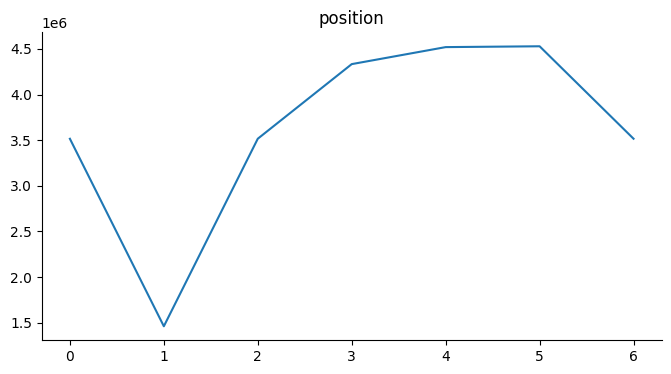

In [12]:
df_repeats['position'].plot(kind='line', figsize=(8, 4), title='position')
plt.gca().spines[['top', 'right']].set_visible(False)

<ipython-input-13-f03aa3d301ac>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(df_repeats, x='position', y='strain', inner='stick', palette='Dark2')


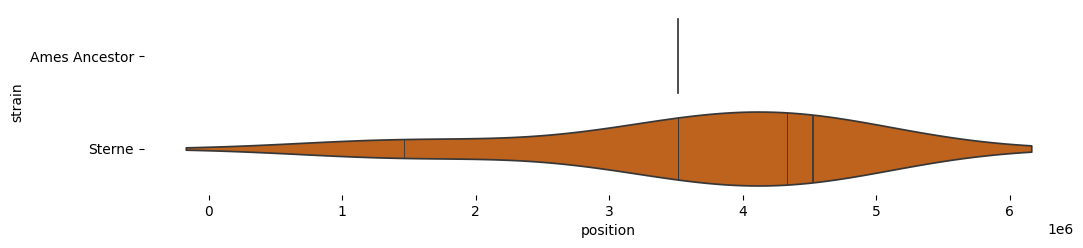

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

figsize = (12, 1.2 * len(df_repeats['strain'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(df_repeats, x='position', y='strain', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

## **Discussion and Conclusion**

### **k-mer Uniqueness Analysis**

- **Observations:**  
  The plot of percentage unique vs. k-mer length shows that for very short reads (k = 6-10), the uniqueness is very low. As the k-mer length increases, the uniqueness increases rapidly (an S-shaped curve), reaching nearly 100% uniqueness for longer reads.

- **Interpretation:**  
  Short k-mers are common in the genome and are found in multiple locations, while longer k-mers become increasingly unique because there are fewer exact repeats. The trend with mismatches shows that allowing even 1 or 2 mismatches significantly reduces uniqueness, as similar sequences are grouped together.

### **Tandem Repeat Analysis**

- **Findings:**  
  The summary table of tandem repeats revealed that the Ames Ancestor strain has 1 instance of a 3-repeat tandem and no 4-repeat instances, while the Sterne strain has 5 instances of 3-repeats and 1 instance of a 4-repeat tandem.

- **Polymorphism:**  
  This suggests the presence of length polymorphism at specific loci, which can serve as potential microsatellite markers for strain differentiation.

### **Imperfect Repeats**

- **Challenges:**  
  In real genomes, tandem repeats are often imperfect, with occasional mismatches or indels that complicate detection.

- **Detection Strategies:**  
  To identify these, one could use a seed-based approach where at least two exact repeats are found, then extend the alignment allowing for errors, or use specialized software such as Tandem Repeats Finder or RepeatMasker.

### **Conclusion**

These analyses demonstrate how read length and mismatch tolerance impact the uniqueness of sequences in a genome, and how tandem repeat polymorphisms can be identified and used as genetic markers. This work has implications for the design of NGS-based re-sequencing projects, particularly in microbial genomics.

In [ ]:
#
# For real life applications with fastQ files uncomment/modify lines below
#
#fastq_file = "insert_here_the_right_name"
#!/bin/bowtie -x $BWT -q $fastq_file -v 1 1> output.txt 2> stderr.txt
#!cp output.txt /content/drive/MyDrive/projects/.